# House Price Prediction Using Machine Learning

# Introduction

House Price Prediction is a machine learning project that aims to estimate the price of a house based on various factors such as area, number of bedrooms, bathrooms, location, and other property features. Accurate house price prediction is important for buyers, sellers, and real estate agencies as it helps them make informed decisions.

In this project, a housing dataset is analyzed using data science and machine learning techniques. The data is first cleaned and preprocessed, followed by Exploratory Data Analysis (EDA) to identify patterns and relationships among features. Machine learning models such as Linear Regression and Random Forest Regressor are then trained to predict house prices. The performance of the models is evaluated using metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The objective of this project is to build an efficient and accurate predictive model that can estimate house prices based on available property information and demonstrate the practical application of machine learning in the real estate domain.


# Step 1:-Import Required Libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# Step 2:- Uploading CSV

In [16]:
from google.colab import files

uploaded = files.upload()

Saving historical_property_transactions.csv to historical_property_transactions (1).csv


# Step 3:- Load the Dataset

In [15]:
df = pd.read_csv('historical_property_transactions.csv')

df.head()

,property_id,square_footage,num_bedrooms,num_bathrooms,year_built,neighborhood_tier,has_pool,distance_to_transit,garage_capacity,sale_price
0,PROP_001,4174,5,4.0,1970,Tier 3,0,7.03,3,361456
1,PROP_002,1860,3,2.5,2001,Tier 3,0,1.94,1,183857
2,PROP_003,2294,3,2.5,1982,Tier 1,1,3.35,1,411300
3,PROP_004,2130,4,3.0,1999,Tier 3,0,8.28,1,197524
4,PROP_005,2095,3,3.0,1992,Tier 2,0,3.00,2,267846


# Step 4:- Dataset Overview

In [18]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          500 non-null    object 
 1   square_footage       500 non-null    int64  
 2   num_bedrooms         500 non-null    int64  
 3   num_bathrooms        500 non-null    float64
 4   year_built           500 non-null    int64  
 5   neighborhood_tier    500 non-null    object 
 6   has_pool             500 non-null    int64  
 7   distance_to_transit  500 non-null    float64
 8   garage_capacity      500 non-null    int64  
 9   sale_price           500 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 39.2+ KB


# Step 5:- Statistical Summary

In [19]:
df.describe()

,square_footage,num_bedrooms,num_bathrooms,year_built,has_pool,distance_to_transit,garage_capacity,sale_price
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2819.38400,3.674000,2.809000,1998.112000,0.216000,4.359360,1.834000,371504.964000
std,1003.67328,1.204419,1.011962,16.137046,0.411926,2.441976,0.867149,151615.382755
min,1001.00000,1.000000,1.000000,1970.000000,0.000000,0.200000,0.000000,120000.000000
25%,1978.75000,3.000000,2.000000,1985.000000,0.000000,2.207500,1.000000,256800.000000
50%,2797.50000,4.000000,3.000000,1999.000000,0.000000,4.515000,2.000000,353945.000000
75%,3708.00000,5.000000,3.500000,2012.000000,0.000000,6.500000,2.000000,461435.000000
max,4499.00000,5.000000,4.500000,2025.000000,1.000000,8.500000,3.000000,829924.000000


# Step 6:- Missing Values Check

In [20]:
df.isnull().sum()

,0
property_id,0
square_footage,0
num_bedrooms,0
num_bathrooms,0
year_built,0
neighborhood_tier,0
has_pool,0
distance_to_transit,0
garage_capacity,0
sale_price,0


# Step 7:- Handle Missing Values

In [21]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

,0
property_id,0
square_footage,0
num_bedrooms,0
num_bathrooms,0
year_built,0
neighborhood_tier,0
has_pool,0
distance_to_transit,0
garage_capacity,0
sale_price,0


# Step 8:- Check Duplicate Records

In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Step 9:- Exploratory Data Analysis (EDA)

Price Distribution

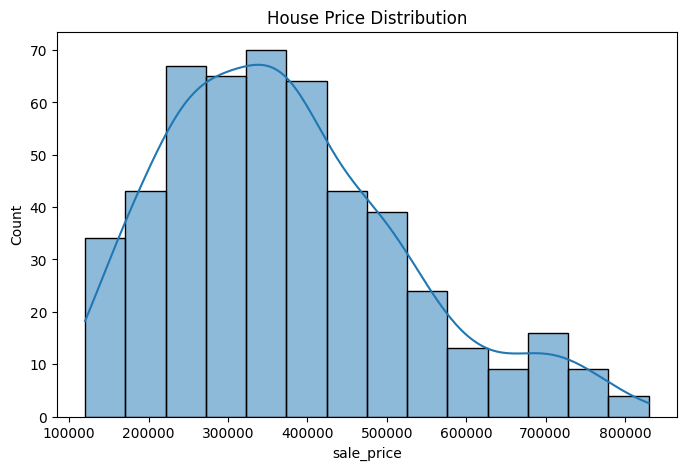

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['sale_price'], kde=True)
plt.title('House Price Distribution')
plt.show()

Correlation Heatmap

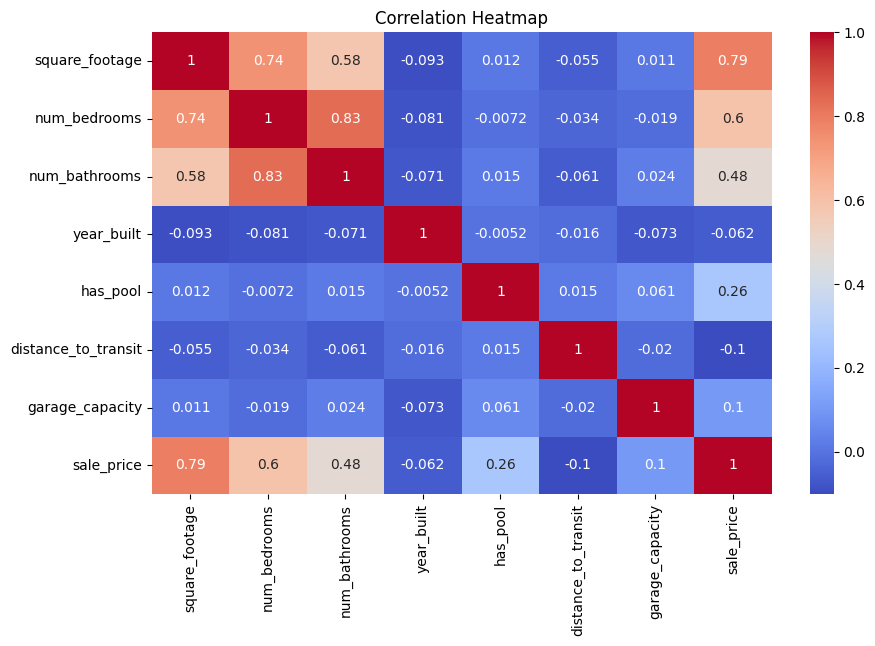

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Area vs Price

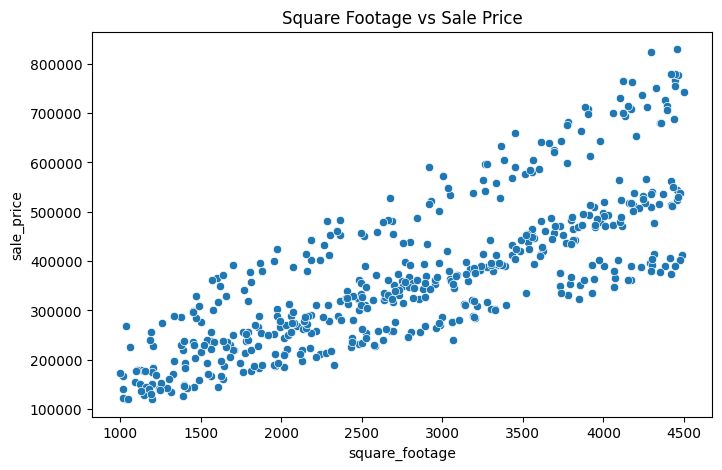

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='square_footage', y='sale_price', data=df)

plt.title("Square Footage vs Sale Price")
plt.show()

Bedrooms vs Price

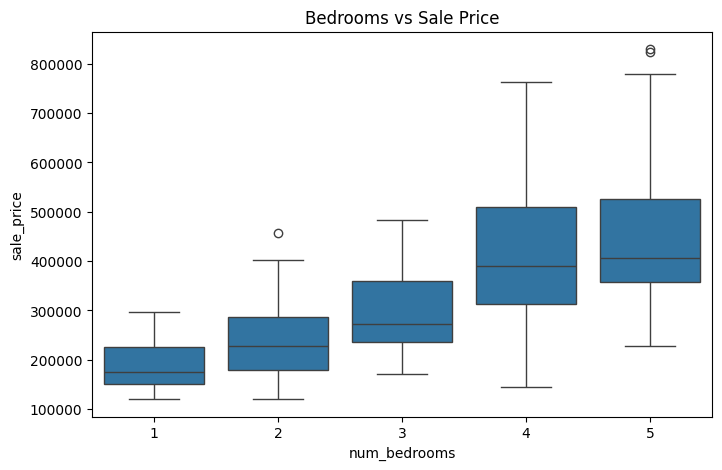

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='num_bedrooms', y='sale_price', data=df)

plt.title("Bedrooms vs Sale Price")
plt.show()

# Step 10:- Feature Engineering

In [27]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,property_id,square_footage,num_bedrooms,num_bathrooms,year_built,neighborhood_tier,has_pool,distance_to_transit,garage_capacity,sale_price
0,0,4174,5,4.0,1970,2,0,7.03,3,361456
1,1,1860,3,2.5,2001,2,0,1.94,1,183857
2,2,2294,3,2.5,1982,0,1,3.35,1,411300
3,3,2130,4,3.0,1999,2,0,8.28,1,197524
4,4,2095,3,3.0,1992,1,0,3.00,2,267846


# Step 11:- Define Features and Target

In [29]:
X = df.drop('sale_price', axis=1)

y = df['sale_price']

# Step 12:- Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 9)
(100, 9)


# Step 13:- Linear Regression Model

In [31]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Step 14:- Evaluate Linear Regression

In [32]:
print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 24144.732865849182
RMSE : 31970.42174087896
R2 Score : 0.9502736479516022


# Step 15:- Decision Tree Regressor

In [39]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Regressor Model Trained Successfully!")

Decision Tree Regressor Model Trained Successfully!


# Step 16:- Evaluation of Decision Tree Regressor

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Mean Absolute Error (MAE):", mae_dt)
print("Root Mean Squared Error (RMSE):", rmse_dt)
print("R² Score:", r2_dt)

Mean Absolute Error (MAE): 21278.14
Root Mean Squared Error (RMSE): 26667.31090942617
R² Score: 0.9654022131892002


# Step 17:- Random Forest Regressor

In [33]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Step 18:- Evaluate Random Forest

In [34]:
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 15142.653499999999
RMSE : 18961.1509050016
R2 Score : 0.9825088139664375


# Step 19:- Compare Models

In [35]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'Random Forest'],
    'R2 Score':[r2_score(y_test, lr_pred),
                r2_score(y_test, rf_pred)]
})

results

,Model,R2 Score
0,Linear Regression,0.950274
1,Random Forest,0.982509


# Step 20:- Feature Importance

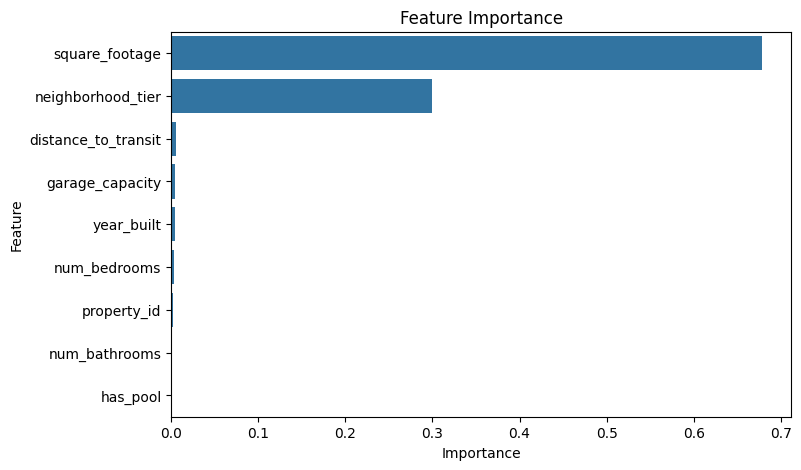

In [36]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# Step 21:-Sample Prediction

In [37]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 484808.57
Actual Price: 474029


# Step 22:- Save the Model

In [38]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion


• House price prediction was performed using machine learning techniques.

• Data preprocessing and exploratory data analysis were conducted.

• Linear Regression and Random Forest models were trained.

• Random Forest achieved better performance and higher prediction accuracy.

• Area, location, and number of bedrooms were among the most important factors affecting house prices.